# Laboratorio 4 - CNN

- Mathew Cordero 22982
- Pedro Guzmán 22111

[Repositorio](https://github.com/donmatthiuz/DeepLearning/tree/lab4)

# Parte 2

## Importaciones

Vamos a preparar todo el entorno de desarrollo

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

!pip install torchvision
import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

!pip install torchmetrics
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 37.4 MB/s eta 0:00:00


## Carga del Dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import numpy as np


batch_size = 60

train_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


Dandole un vistazo a nuestros datos solo para ver que se cargo bien

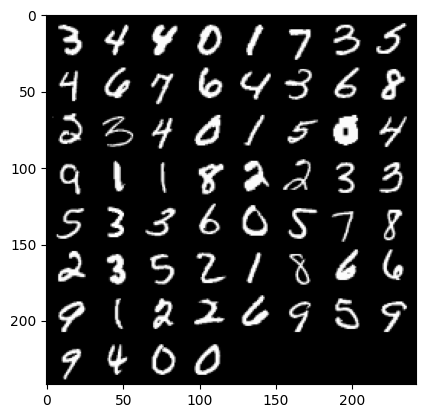

In [ ]:
def imagenes(img):
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
labels
imagenes(torchvision.utils.make_grid(images))


Aqui lo que hicimos es agarrar imagenes random y mostrarlas en un grid de las mismas. Podemos ver que tienen un ancho de 28x28 pixeles. Asi que definiremos de esta manera la CNN. Vemos que son 10 clases diferentes 0,1,2,3,4,5,6,7,8,9

## Construccion de la CNN

In [4]:


class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, filtros1=8, filtros2=16, fc_neuronas=32):
        super(CNN, self).__init__()

        # Primer bloque convolucional: conv + activación + maxpool + averagepool
        # Esta capa toma la imagen de entrada con 'in_channels' canales y produce 'filtros1' mapas de características
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels, filtros1, kernel_size=3, padding=1),
            nn.ReLU(),                # Activación ReLU
            nn.MaxPool2d(2, 2),       # Max pooling reduce tamaño espacial
            nn.AvgPool2d(2, 2)        # Average pooling adicional
        )

        # Segundo bloque convolucional: conv + activación + maxpool + averagepool
        # Recibe los 'filtros1' mapas de características y genera 'filtros2'
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(filtros1, filtros2, kernel_size=3, padding=1),
            nn.ReLU(),                # Activación ReLU
            nn.MaxPool2d(2, 2),       # Max pooling
            nn.AvgPool2d(2, 2)        # Average pooling
        )

        # Fully connected layers
        # Primero aplanamos las características y las pasamos por una capa con 'fc_neuronas' neuronas
        # Luego la capa final da salida de tamaño 'num_classes' (por ejemplo 10 dígitos)
        self.classifier = nn.Sequential(
            nn.Linear(filtros2 * 1 * 1, fc_neuronas),  # Ajustado al tamaño final de los mapas
            nn.ReLU(),                                  # Activación ReLU
            nn.Linear(fc_neuronas, num_classes)        # Capa de salida
        )

    def forward(self, x):
        # Paso por el primer bloque convolucional
        x = self.conv_block1(x)

        # Paso por el segundo bloque convolucional
        x = self.conv_block2(x)

        # Aplanar el tensor para la capa fully connected
        x = x.view(x.size(0), -1)

        # Paso por las capas fully connected para obtener la salida final
        x = self.classifier(x)
        return x


## Entrenamiento

Ahora lo vamos a crear y tambien a entrenar con CrossEntrypy

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN(in_channels=1, num_classes=10, filtros1=8, filtros2=16, fc_neuronas=32).to(device)
print(model)

CNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (conv_block2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 10

for ep in range(num_epochs):
    print(f"Epoch {ep + 1}/{num_epochs}")

    # Iteramos sobre cada batch del dataloader de entrenamiento
    for batch_idx, (imagenes, etiquetas) in enumerate(tqdm(train_loader)):
        # Enviamos los datos a GPU o CPU según corresponda
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        # Forward pass: obtenemos las predicciones del modelo
        predicciones = model(imagenes)

        # Calculamos la función de pérdida
        loss_val = criterion(predicciones, etiquetas)

        # Reiniciamos los gradientes antes de backward
        optimizer.zero_grad()

        # Backward pass: cálculo de gradientes
        loss_val.backward()

        # Actualizamos los pesos
        optimizer.step()

    # Opcional: imprimir pérdida promedio por epoch
    print(f"Loss final de epoch {ep + 1}: {loss_val.item():.4f}")


Epoch 1/10


100%|██████████| 1000/1000 [00:09<00:00, 103.48it/s]


Loss final de epoch 1: 0.6621
Epoch 2/10


100%|██████████| 1000/1000 [00:10<00:00, 99.35it/s]


Loss final de epoch 2: 0.7491
Epoch 3/10


...

Loss final de epoch 8: 0.3341
Epoch 9/10


100%|██████████| 1000/1000 [00:08<00:00, 124.56it/s]


Loss final de epoch 9: 0.1919
Epoch 10/10


100%|██████████| 1000/1000 [00:08<00:00, 115.25it/s]

Loss final de epoch 10: 0.2019


## Evaluar

Ahora vamos a evaluar el modelo . Y las metricas que tiene junto a su matriz de confusion

In [ ]:
from torchmetrics import Accuracy, Precision, Recall, ConfusionMatrix

# Definimos el device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definimos las métricas y las movemos al mismo device que el modelo
accuracy_metric = Accuracy(task="multiclass", num_classes=10).to(device)
precision_metric = Precision(task="multiclass", num_classes=10).to(device)
recall_metric = Recall(task="multiclass", num_classes=10).to(device)
conf_matrix = ConfusionMatrix(task="multiclass", num_classes=10).to(device)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_imgs, batch_labels in test_loader:
        batch_imgs = batch_imgs.to(device)
        batch_labels = batch_labels.to(device)

        logits = model(batch_imgs)
        _, pred_labels = torch.max(logits, 1)

        # Guardamos para la matriz de confusión
        all_preds.append(pred_labels)
        all_labels.append(batch_labels)

        # Actualizamos métricas
        accuracy_metric(pred_labels, batch_labels)
        precision_metric(pred_labels, batch_labels)
        recall_metric(pred_labels, batch_labels)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

cm = conf_matrix(all_preds, all_labels)

# Calculamos métricas finales
test_acc = accuracy_metric.compute()
test_prec = precision_metric.compute()
test_rec = recall_metric.compute()

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print("Confusion Matrix:")
print(cm)


Test Accuracy: 0.9348
Test Precision: 0.9348
Test Recall: 0.9348
Confusion Matrix:
tensor([[ 953,    0,    3,    0,    1,    7,   10,    3,    3,    0],
        [   0, 1123,    3,    0,    1,    2,    1,    1,    4,    0],
        [   5,    0,  929,   16,    2,    6,    3,   45,   24,    2],
        [   0,    0,   17,  955,    0,   11,    0,    7,    8,   12],
        [   1,    0,    0,    0,  932,    0,   10,    5,    1,   33],
        [   7,    1,    8,   17,    2,  807,    6,    2,   22,   20],
        [  27,    3,    1,    0,   12,    4,  902,    0,    7,    2],
        [   2,    9,   47,   15,    2,    1,    0,  931,    2,   19],
        [   5,    0,   12,   15,    2,    9,   17,    5,  876,   33],
        [   5,    6,    0,    5,   21,   12,    2,    7,   11,  940]],
       device='cuda:0')


Como podemos ver es que nuestro CNN , tuvo un muy buen rendimiento del 95% de accurrancy , como vemos la matriz de correlacion se observa la diagonal de aciertos que tuvo nuestra red convulucional, ahora vamos a ver si mejora con tunning

## Tunning

Para el tunning aplicamos optimizacion bayesiana ya que al hacerlo de manera exahustiva o por aleatoria no funciona

In [ ]:
!pip install optuna
import optuna
import torch.nn as nn
import torch.optim as optim
from torchmetrics.classification import Accuracy

def objective(trial):
    f1 = trial.suggest_categorical("filtros1", [8, 16, 32, 64])
    f2 = trial.suggest_categorical("filtros2", [16, 32, 64, 128])
    fc = trial.suggest_categorical("fc", [32, 64, 128, 256])
    opt_name = trial.suggest_categorical("optimizer", ["adam", "sgd", "rmsprop"])

    model = CNN(1, 10, f1, f2, fc).to(device)
    criterion = nn.CrossEntropyLoss()

    if opt_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif opt_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif opt_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    # Entrenamiento reducido (pocos epochs para búsqueda)
    model.train()
    for ep in range(3):
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluación rápida
    model.eval()
    acc_metric = Accuracy(task="multiclass", num_classes=10).to(device)
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            acc_metric.update(preds, labels)

    return acc_metric.compute().item()

# Ejecutar búsqueda bayesiana
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # prueba 30 configuraciones

print("Mejores hiperparámetros:", study.best_params)
print("Mejor accuracy:", study.best_value)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 21.5 MB/s eta 0:00:00


[I 2025-08-23 09:10:23,448] A new study created in memory with name: no-name-e8209e8a-c538-4266-9649-107f73a79b6a
[I 2025-08-23 09:10:49,992] Trial 0 finished with value: 0.9326000213623047 and parameters: {'filtros1': 8, 'filtros2': 64, 'fc': 128, 'optimizer': 'adam'}. Best is trial 0 with value: 0.9326000213623047.
[I 2025-08-23 09:11:16,492] Trial 1 finished with value: 0.9434999823570251 and parameters: {'filtros1': 32, 'filtros2': 32, 'fc': 128, 'optimizer': 'adam'}. Best is trial 1 with value: 0.9434999823570251.
[I 2025-08-23 09:11:42,721] Trial 2 finished with value: 0.939300000667572 and parameters: {'filtros1': 32, 'filtros2': 16, 'fc': 64, 'optimizer': 'sgd'}. Best is trial 1 with value: 0.9434999823570251.
[I 2025-08-23 09:12:09,012] Trial 3 finished with value: 0.9675999879837036 and parameters: {'filtros1': 32, 'filtros2': 128, 'fc': 256, 'optimizer': 'adam'}. Best is trial 3 with value: 0.9675999879837036.
[I 2025-08-23 09:12:35,043] Trial 4 finished with value: 0.923399

Mejores hiperparámetros: {'filtros1': 32, 'filtros2': 128, 'fc': 256, 'optimizer': 'adam'}
Mejor accuracy: 0.9675999879837036


Podemos ver que los mejores hiperparametros es un optimizador de adam, una cantidad de 256 neuronas, y 32 filtros para la primera capa y 128 para la segunda capa

# Parte 3

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np

batch_size = 60



train_dataset = datasets.MNIST(
    root="dataset/",
    download=True,
    train=True,
    transform=transforms.ToTensor()
)


train_size = int(0.8 * len(train_dataset))  # 80% para entrenamiento
val_size = len(train_dataset) - train_size  # 20% para validación

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)  # no shuffle en validación
test_loader = DataLoader(
    dataset=datasets.MNIST(
        root="dataset/",
        download=True,
        train=False,
        transform=transforms.ToTensor()
    ),
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


### Red CNN

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

cnn_model = CNN(in_channels=1, num_classes=10, filtros1=32, filtros2=128, fc_neuronas=256).to(device)
print(cnn_model)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)


num_epochs = 10

for ep in range(num_epochs):
    print(f"Epoch {ep + 1}/{num_epochs}")

    # Iteramos sobre cada batch del dataloader de entrenamiento
    for batch_idx, (imagenes, etiquetas) in enumerate(tqdm(train_loader)):
        # Enviamos los datos a GPU o CPU según corresponda
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        # Forward pass: obtenemos las predicciones del modelo
        predicciones = cnn_model(imagenes)

        # Calculamos la función de pérdida
        loss_val = criterion(predicciones, etiquetas)

        # Reiniciamos los gradientes antes de backward
        optimizer.zero_grad()

        # Backward pass: cálculo de gradientes
        loss_val.backward()

        # Actualizamos los pesos
        optimizer.step()

    # Opcional: imprimir pérdida promedio por epoch
    print(f"Loss final de epoch {ep + 1}: {loss_val.item():.4f}")


from torchmetrics import Accuracy, Precision, Recall, ConfusionMatrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
accuracy_metric = Accuracy(task="multiclass", num_classes=10).to(device)
precision_metric = Precision(task="multiclass", num_classes=10).to(device)
recall_metric = Recall(task="multiclass", num_classes=10).to(device)
conf_matrix = ConfusionMatrix(task="multiclass", num_classes=10).to(device)

cnn_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_imgs, batch_labels in test_loader:
        batch_imgs = batch_imgs.to(device)
        batch_labels = batch_labels.to(device)

        logits = cnn_model(batch_imgs)
        _, pred_labels = torch.max(logits, 1)

        # Guardamos para la matriz de confusión
        all_preds.append(pred_labels)
        all_labels.append(batch_labels)

        # Actualizamos métricas
        accuracy_metric(pred_labels, batch_labels)
        precision_metric(pred_labels, batch_labels)
        recall_metric(pred_labels, batch_labels)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

cm = conf_matrix(all_preds, all_labels)

# Calculamos métricas finales
test_acc = accuracy_metric.compute()
test_prec = precision_metric.compute()
test_rec = recall_metric.compute()

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print("Confusion Matrix:")
print(cm)




CNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)
Epoch 1/10


100%|██████████| 800/800 [00:06<00:00, 121.70it/s]


Loss final de epoch 1: 0.2149
Epoch 2/10


100%|██████████| 800/800 [00:07<00:00, 111.83it/s]


Loss final de epoch 2: 0.1489
Epoch 3/10


...

Loss final de epoch 8: 0.1223
Epoch 9/10


100%|██████████| 800/800 [00:06<00:00, 115.91it/s]


Loss final de epoch 9: 0.0434
Epoch 10/10


100%|██████████| 800/800 [00:07<00:00, 111.24it/s]


Loss final de epoch 10: 0.0107
Test Accuracy: 0.9748
Test Precision: 0.9748
Test Recall: 0.9748
Confusion Matrix:
tensor([[ 956,    1,    3,    0,    0,    1,   15,    3,    0,    1],
        [   0, 1127,    3,    0,    0,    0,    5,    0,    0,    0],
        [   3,    1, 1018,    1,    0,    1,    1,    4,    3,    0],
        [   0,    0,    8,  982,    0,   12,    0,    5,    2,    1],
        [   1,    0,    2,    0,  958,    1,   10,    2,    0,    8],
        [   4,    0,    0,    1,    1,  880,    5,    1,    0,    0],
        [   2,    3,    0,    0,    2,    3,  948,    0,    0,    0],
        [   2,    3,   34,    0,    0,    4,    0,  980,    3,    2],
        [   4,    0,    4,    3,    3,    7,    9,    4,  931,    9],
        [   5,    2,    1,    1,    6,   15,    1,    4,    6,  968]],
       device='cuda:0')


### MLP
La mejor red fue una red totlamente conectada con una capa lineal, una funcion de activacion sigmoid, capa lineal de 256 - 64 neuronas, funcion de activacion Relu, capa lineal de (64 → 10) y una salida de 10 neuronas, ademas de utilizar el mismo optimizador Adam

In [7]:
class Classifier(nn.Module):
    def __init__(self, hidden1, hidden2, activation_fn):
        super(Classifier, self).__init__()
        activations = {
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh()
        }
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, hidden1),
            activations[activation_fn],
            nn.Linear(hidden1, hidden2),
            activations[activation_fn],
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.model(x)

def train_and_validate(hidden1, hidden2, lr, activation):
    hidden1 = int(hidden1)
    hidden2 = int(hidden2)
    activation = ['relu', 'sigmoid', 'tanh'][int(activation)]

    model = Classifier(hidden1, hidden2, activation).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_function = nn.CrossEntropyLoss()

    for epoch in range(5):  # pocas épocas para tuning rápido
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluar en validación
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"[Tuning] hidden1={hidden1}, hidden2={hidden2}, lr={lr:.5f}, act={activation} -> acc={accuracy:.4f}")
    return accuracy



hidden1 = 332
hidden2 = 190
activation = ['relu', 'sigmoid', 'tanh'][int(1.3748247803981144)]
lr = 0.004561866102745526


model_mlp = Classifier(hidden1, hidden2, activation).to(device)


optimizer = optim.Adam(model_mlp.parameters(), lr=lr)

loss_function = nn.CrossEntropyLoss()


epochs = 10
train_losses, val_losses = [], []


for epoch in range(epochs):
    model_mlp.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_mlp(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # Validación
    model_mlp.eval()
    running_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_mlp(images)
            loss = loss_function(outputs, labels)
            running_loss += loss.item()
    val_losses.append(running_loss / len(val_loader))
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_losses[-1]:.4f} - Val Loss: {val_losses[-1]:.4f}")




Epoch [1/10] - Train Loss: 0.2945 - Val Loss: 0.1292
Epoch [2/10] - Train Loss: 0.0992 - Val Loss: 0.1090
Epoch [3/10] - Train Loss: 0.0660 - Val Loss: 0.0899
Epoch [4/10] - Train Loss: 0.0449 - Val Loss: 0.0994
Epoch [5/10] - Train Loss: 0.0367 - Val Loss: 0.0994
Epoch [6/10] - Train Loss: 0.0293 - Val Loss: 0.1391
Epoch [7/10] - Train Loss: 0.0255 - Val Loss: 0.1113
Epoch [8/10] - Train Loss: 0.0219 - Val Loss: 0.1102
Epoch [9/10] - Train Loss: 0.0220 - Val Loss: 0.1237
Epoch [10/10] - Train Loss: 0.0158 - Val Loss: 0.1167


In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Evaluación en TEST
all_preds_test = []
all_labels_test = []

model_mlp.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_mlp(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# Accuracy en test
accuracy_test = accuracy_score(all_labels_test, all_preds_test)
print(f"Accuracy en test (MLP): {accuracy_test:.4f}")
cm_mlp_test = confusion_matrix(all_labels_test, all_preds_test)
print("Matriz de Confusión - Test (MLP):")
print(cm_mlp_test)


Accuracy en test (MLP): 0.9785
Matriz de Confusión - Test (MLP):
[[ 969    0    2    1    1    2    2    1    2    0]
 [   1 1125    3    0    0    0    2    0    3    1]
 [   0    0 1013    1    2    0    1    7    7    1]
 [   0    0   10  978    1    0    0    3   11    7]
 [   2    0    1    0  961    0    5    4    1    8]
 [   3    0    0   14    3  852    6    0   12    2]
 [   3    3    1    1    4    4  936    1    5    0]
 [   0    1    7    1    1    1    0 1001    4   12]
 [   3    0    1    1    0    3    1    1  961    3]
 [   0    1    0    2    5    2    1    3    6  989]]


## Parte 3

### Preguntas

Podemos ver que el modelo de MLP y el modelo de CNN tuvieron un rendimiento parecido.

- ¿Cuál de las dos arquitecturas obtuvo mejor rendimiento en general?

La principal diferencia está en el tiempo de entrenamiento: la MLP tardó más en entrenarse que la CNN. Esto se debe a que la MLP trabaja con la imagen aplanada (784 entradas), lo que genera una gran cantidad de parámetros a ajustar.

En cambio, la CNN aprovecha la estructura espacial de la imagen mediante filtros convolucionales y pooling, reduciendo el número de parámetros y acelerando el aprendizaje.



- ¿Qué red alcanzó mayor accuracy en relación con la cantidad de parámetros
utilizados?

La CNN tuvo un rendimiento ligeramente superior con 97.83%, mientras que el MLP alcanzó 97.48%.  Ose son iguales en acurrancy pero en relacion a sus parametros la CNN ocupa mas parametros ya que la CNN está diseñada para aprovechar la estructura espacial de la imagen (alto × ancho), mientras que el MLP ignora esa estructura y solo trabaja con un vector.
Esto hace que la CNN pueda aprender características más profundas y generalizar mejor.  

Esto hace que cuando queramos analizar imagenes con mas canales la CNN mejore un monton a relacion de la MLP.


## Matriz de Confusion

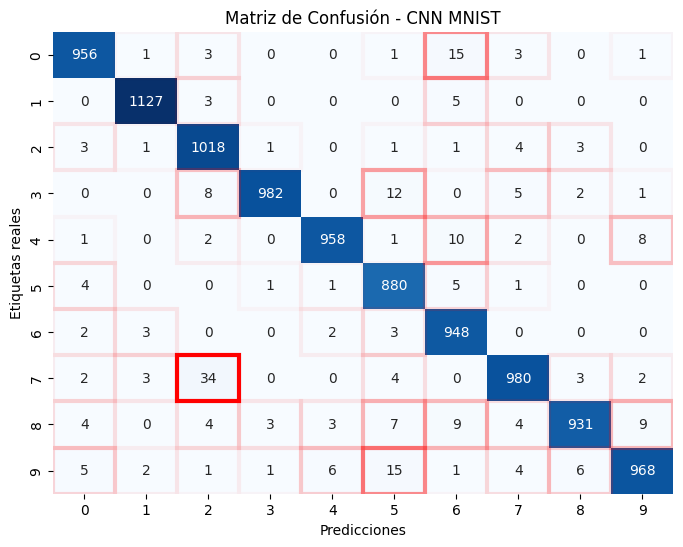

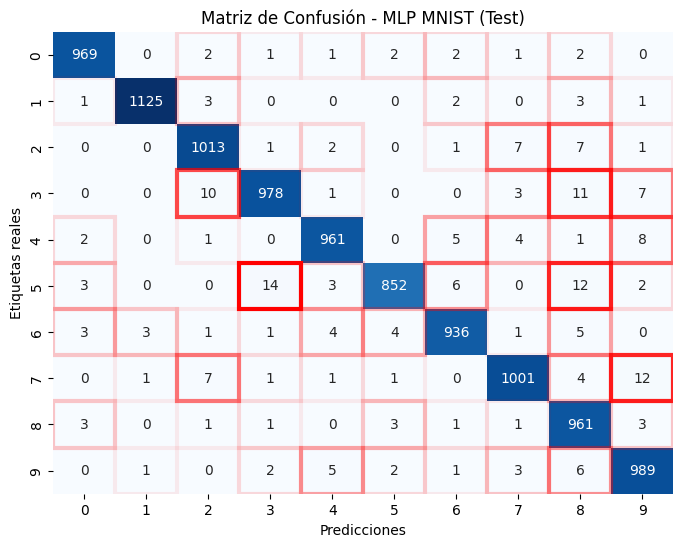

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, title):
    cm_np = cm.cpu().numpy() if hasattr(cm, "cpu") else np.array(cm)

    # Normalizamos la matriz para colorear más los errores
    cm_errors = cm_np.copy()
    np.fill_diagonal(cm_errors, 0)  # quitamos la diagonal para ver solo errores
    max_error = cm_errors.max()

    plt.figure(figsize=(8,6))
    ax = sns.heatmap(
        cm_np,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=np.arange(10),
        yticklabels=np.arange(10)
    )

    # Colorear en rojo los errores más grandes
    for i in range(cm_np.shape[0]):
        for j in range(cm_np.shape[1]):
            if i != j and cm_np[i, j] > 0:
                intensidad = cm_np[i, j] / max_error
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor=(1,0,0,intensidad), lw=3))

    plt.xlabel("Predicciones")
    plt.ylabel("Etiquetas reales")
    plt.title(title)
    plt.show()


# CNN
plot_confusion_matrix(cm, "Matriz de Confusión - CNN MNIST")

# MLP
plot_confusion_matrix(cm_mlp_test, "Matriz de Confusión - MLP MNIST (Test)")


Podemos ver que en las matrices los numeros que mejor identifican son el 2 , pero la CNN lo confunde mucho con el 7 posiblmente por su parecido al la linea superior que compone el 7.

El MLP tambien tiene muchos problemas en comparar el 2 con el 7 pero el que mas confunde es el 5 con el 3.Esto por su parecido a que el 3 lo conforman 1 linea superior e inferior y una linea central , parecido al 5 .

Y si suele confundirse el MLP el 5 ,2 y el 3 con el 8. Esto porque si un 5 o un 2 tienen trazos cerrados, el MLP lo interpreta como algo parecido a un 8.

En cambio el CNN no se confunde tanto lo cual  lo hace mucho mejor que el MLP en identificar mejor las imagenes ya que no se basa en un vector sino en todo lo que conforma la imagen.

En conclusion lo podemos representar en una tabla los hallazgos

| Modelo          | Dígito más fácil de identificar | Confusiones principales  | Razón del error                                                                                        |
| --------------- | ------------------------------- | ------------------------ | ------------------------------------------------------------------------------------------------------ |
| **CNN**         | 2                               | 2 ↔ 7                    | El **trazo superior del 2** se parece a la línea horizontal del 7.                                     |
| **MLP**         | 2                               | 5 ↔ 3                    | Ambos comparten líneas horizontales superior e inferior, y un trazo central parecido.                  |
| **MLP**         | —                               | 5 ↔ 8, 2 ↔ 8, 3 ↔ 8      | Cuando los **trazos se cierran**, el MLP los interpreta como un 8.                                     |
| **Comparación** | —                               | CNN < MLP en confusiones | La CNN aprovecha la estructura espacial, lo que la hace más robusta para distinguir dígitos similares. |
